# ShortGPT: Layer Pruning via Block Influence
**CAP6614 - Efficient AI | Team 7**

This notebook implements the full ShortGPT pipeline:
1. Load Llama-2-7B in 4-bit quantization
2. Load WikiText-2 calibration data
3. Compute Block Influence (BI) scores for every layer
4. Visualize layer redundancy
5. Prune least-important layers
5.5 Baseline Perplexity (Before Pruning)
5.6 Evaluate Unpruned Model (Test A)
6. Define the Benchmarking
6.5 Layer Removal
7. Evaluate Pruned Model Perplexity
7.5 Measurement
8. Evalaute Pruned Model General Questions (Test B)
9. Save Pruned Model
10. Summay Table

**Paper:** Men et al., *"ShortGPT: Layers in Large Language Models are More Redundant Than You Expect"* (arXiv 2403.03853)

## 0. Setup

Run this cell first on Colab. If running locally, `pip install -r requirements.txt` instead.

In [ ]:
# Colab only - skip if running locally with requirements.txt installed
!pip install -q -U bitsandbytes transformers accelerate datasets sentencepiece matplotlib tqdm "protobuf<6.0.0,>=5.29.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.7 MB/s eta 0:00:00


In [ ]:
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


---
## 1. Load Model in 4-bit Quantization

We use `bitsandbytes` NF4 quantization to fit Llama-2-7B into ~5 GB VRAM.

**Note:** `meta-llama/Llama-2-7b-hf` requires:
1. A HuggingFace account
2. Accepting Meta's license at https://huggingface.co/meta-llama/Llama-2-7b-hf
3. A HF token (set via `huggingface-cli login` or the cell below)

In [ ]:
# Authenticate with HuggingFace (run once)
# Colab - will prompt for token
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
MODEL_ID = "meta-llama/Llama-2-7b-hf"

# 4-bit NF4 quantization config
# double_quant squeezes out a bit more memory savings on top of NF4
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading tokenizer from {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Llama doesn't set a pad token by default

print(f"Loading model in 4-bit NF4...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",          # let accelerate handle device placement
    torch_dtype=torch.bfloat16,
)
model.eval()  # inference only, no training

NUM_LAYERS = len(model.model.layers)
HIDDEN_DIM = model.config.hidden_size
print(f"\nModel loaded successfully!")
print(f"  Layers:     {NUM_LAYERS}")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading tokenizer from meta-llama/Llama-2-7b-hf...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]


Model loaded successfully!
  Layers:     32
  Hidden dim: 4096
  Parameters: 3.50B


---
## 2. Load Calibration Data (WikiText-2)

We sample random subsequences from the WikiText-2 training set.
This is the standard calibration approach used by SparseGPT, WANDA, and ShortGPT.

In [ ]:
SEQLEN = 512       # tokens per sample (512 works on T4; paper uses 2048)
NSAMPLES = 128     # number of calibration samples (standard for SparseGPT/WANDA)


def get_wikitext2_calibration(nsamples, seqlen, tokenizer, seed=42):
    """Load WikiText-2 and return calibration samples + test encoding."""
    traindata = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
    testdata = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

    # Concat all training text into one long string, then tokenize it all at once
    trainenc = tokenizer(
        " ".join(traindata["text"]),
        return_tensors="pt",
    )
    testenc = tokenizer(
        "\n\n".join(testdata["text"]),
        return_tensors="pt",
    )

    # Grab random windows from the tokenized training data
    random.seed(seed)
    samples = []
    for _ in range(nsamples):
        i = random.randint(0, trainenc.input_ids.shape[1] - seqlen - 1)
        samples.append(trainenc.input_ids[:, i : i + seqlen])  # shape: (1, seqlen)

    return samples, testenc


print("Loading WikiText-2...")
calibration_data, test_encoding = get_wikitext2_calibration(
    NSAMPLES, SEQLEN, tokenizer, seed=SEED
)
print(f"Calibration: {len(calibration_data)} samples x {SEQLEN} tokens")
print(f"Test set: {test_encoding.input_ids.shape[1]} tokens")

Loading WikiText-2...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Calibration: 128 samples x 512 tokens
Test set: 341469 tokens


---
## 3. Block Influence (BI) Metric

For each layer *i*, Block Influence measures how much the layer changes
the hidden state passing through it:

$$\text{BI}_i = 1 - \mathbb{E}_{X,t}\left[\frac{X_{i,t}^\top \cdot X_{i+1,t}}{\|X_{i,t}\| \cdot \|X_{i+1,t}\|}\right]$$

- **BI close to 0** = layer barely changes anything (redundant, safe to remove)
- **BI close to 1** = layer makes big changes to the hidden state (important, keep it)

In [ ]:
def block_influence(x_in, x_out):
    """Compute per-token Block Influence between layer input and output.
    BI = 1 - cosine_sim(input, output). Returns (B*S,) tensor of scores in [0,1].
    """
    B, S, D = x_in.shape

    # Flatten batch + sequence dims so we get one cosine sim value per token
    flat_in = x_in.reshape(-1, D).float()
    flat_out = x_out.reshape(-1, D).float()

    sim = F.cosine_similarity(flat_in, flat_out, dim=-1)  # shape: (B*S,)
    sim = sim.nan_to_num(nan=0.5)  # safety net for zero-norm edge cases
    return 1.0 - sim

---
## 4. Compute BI Scores Across All Layers

We forward-pass all calibration samples through the model with `output_hidden_states=True`.
This gives us the hidden state at every layer boundary without needing manual hooks.

`hidden_states[i]` = input to layer `i`, `hidden_states[i+1]` = output of layer `i`.

In [ ]:
def compute_bi_scores(model, calibration_data, num_layers):
    """Compute average BI score for every layer across all calibration samples."""
    bi_scores = [0.0] * num_layers
    total_tokens = 0

    with torch.no_grad():
        for inp in tqdm(calibration_data, desc="Computing BI scores"):
            outputs = model(
                input_ids=inp.to(DEVICE),
                output_hidden_states=True,  # this gives us hidden states at every layer
                use_cache=False,
                return_dict=True,
            )
            # hidden_states is a tuple of (num_layers + 1) tensors
            # hidden_states[i] = input to layer i
            # hidden_states[i+1] = output of layer i
            hidden_states = outputs.hidden_states
            n_tokens = inp.shape[1]
            total_tokens += n_tokens

            for i in range(num_layers):
                bi = block_influence(hidden_states[i], hidden_states[i + 1])
                bi_scores[i] += bi.sum().item()

    # Average over all tokens across all samples
    bi_scores = [s / total_tokens for s in bi_scores]
    return bi_scores


print(f"Running {NSAMPLES} calibration samples through {NUM_LAYERS} layers...")
bi_scores = compute_bi_scores(model, calibration_data, NUM_LAYERS)

print("\nBlock Influence scores per layer:")
for i, score in enumerate(bi_scores):
    bar = "█" * int(score * 100)
    print(f"  Layer {i:2d}: {score:.4f}  {bar}")

Running 128 calibration samples through 32 layers...


Computing BI scores: 100%|██████████| 128/128 [09:02<00:00,  4.24s/it]


Block Influence scores per layer:
  Layer  0: 0.3974  ███████████████████████████████████████
  Layer  1: 0.2517  █████████████████████████
  Layer  2: 0.1860  ██████████████████
  Layer  3: 0.1532  ███████████████
  Layer  4: 0.1593  ███████████████
  Layer  5: 0.1587  ███████████████
  Layer  6: 0.1528  ███████████████
  Layer  7: 0.1467  ██████████████
  Layer  8: 0.1392  █████████████
  Layer  9: 0.1305  █████████████
  Layer 10: 0.1229  ████████████
  Layer 11: 0.1098  ██████████
  Layer 12: 0.1077  ██████████
  Layer 13: 0.1082  ██████████
  Layer 14: 0.1034  ██████████
  Layer 15: 0.1066  ██████████
  Layer 16: 0.1061  ██████████
  Layer 17: 0.0868  ████████
  Layer 18: 0.0760  ███████
  Layer 19: 0.0644  ██████
  Layer 20: 0.0654  ██████
  Layer 21: 0.0493  ████
  Layer 22: 0.0480  ████
  Layer 23: 0.0406  ████
  Layer 24: 0.0373  ███
  Layer 25: 0.0385  ███
  Layer 26: 0.0367  ███
  Layer 27: 0.0353  ███
  Layer 28: 0.0383  ███
  Layer 29: 0.0400  ████
  Layer 30: 0.0655  ███

---
## 5. Visualize Layer Importance

This reproduces **Figure 3** from the ShortGPT paper, the layer importance plot.
Expect to see: first few layers and the last layer have high BI; middle-to-later layers are redundant.

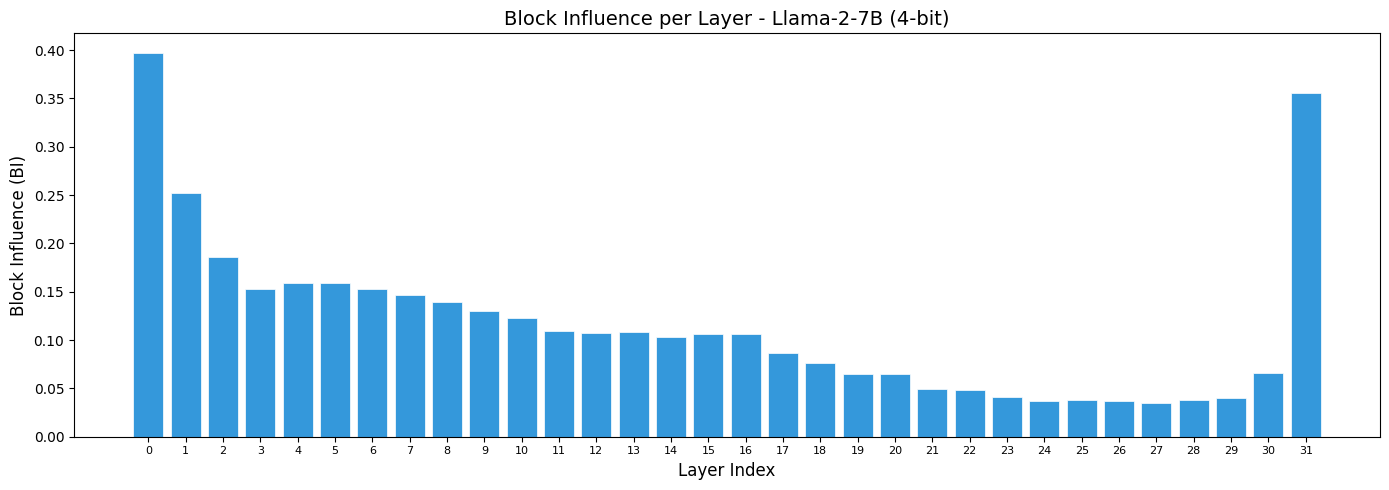

Saved: bi_scores.png

Most redundant layers (lowest BI):  [27, 26, 24, 28, 25]
Most critical layers (highest BI):   [4, 2, 1, 31, 0]


In [ ]:
def plot_bi_scores(bi_scores, model_name="Llama-2-7B (4-bit)", n_prune=None):
    """Bar chart of BI scores per layer, with optional pruning threshold."""
    fig, ax = plt.subplots(figsize=(14, 5))

    layers = list(range(len(bi_scores)))

    # Color bars: red = will be pruned, blue = kept
    if n_prune is not None:
        prune_set = set(np.argsort(bi_scores)[:n_prune])
        colors = ["#e74c3c" if i in prune_set else "#3498db" for i in layers]
    else:
        colors = "#3498db"

    ax.bar(layers, bi_scores, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Layer Index", fontsize=12)
    ax.set_ylabel("Block Influence (BI)", fontsize=12)
    ax.set_title(f"Block Influence per Layer - {model_name}", fontsize=14)
    ax.set_xticks(layers)
    ax.set_xticklabels(layers, fontsize=8)

    if n_prune is not None:
        # Add threshold line
        threshold = sorted(bi_scores)[n_prune]
        ax.axhline(y=threshold, color="#e74c3c", linestyle="--", alpha=0.7,
                   label=f"Pruning threshold (remove {n_prune} layers)")
        ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig("bi_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: bi_scores.png")


# Plot without pruning threshold first
plot_bi_scores(bi_scores)

# Identify most and least important layers
ranked = np.argsort(bi_scores)
print(f"\nMost redundant layers (lowest BI):  {ranked[:5].tolist()}")
print(f"Most critical layers (highest BI):   {ranked[-5:].tolist()}")

---
## 5.5 Baseline Perplexity (Before Pruning)

We need the unpruned model's perplexity so we have something to compare against after pruning.
**Run this before the pruning step.**

In [ ]:
def evaluate_perplexity(model, test_encoding, seqlen=512):
    """
    Calculate perplexity on a test set using non-overlapping windows.
    Lower perplexity = better predictions.
    """
    test_ids = test_encoding.input_ids
    n_tokens = test_ids.shape[1]
    nlls = []

    with torch.no_grad():
        for i in tqdm(range(0, n_tokens - seqlen, seqlen), desc="Evaluating PPL"):
            batch = test_ids[:, i : i + seqlen].to(DEVICE)
            outputs = model(
                input_ids=batch,
                use_cache=False,
                return_dict=True,
            )
            # Shift logits: predict token i+1 from position i
            # Cast to float32 before CE to avoid precision blow-up in fp16/bf16
            logits = outputs.logits[:, :-1, :].float().contiguous()
            labels = batch[:, 1:].contiguous()
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                reduction="mean",
            )
            nlls.append(loss.item())

    avg_nll = np.mean(nlls)
    ppl = np.exp(avg_nll)
    return ppl


# Get the baseline BEFORE we prune anything
print("Evaluating BASELINE (unpruned) perplexity on WikiText-2 test set...")
baseline_ppl = evaluate_perplexity(model, test_encoding, seqlen=SEQLEN)
print(f"\nBaseline PPL (unpruned): {baseline_ppl:.2f}")
print("(For reference: original Llama-2-7B PPL on WikiText-2 is around 5.5)")

Evaluating BASELINE (unpruned) perplexity on WikiText-2 test set...


Evaluating PPL: 100%|██████████| 666/666 [46:30<00:00,  4.19s/it]


Baseline PPL (unpruned): 7.53
(For reference: original Llama-2-7B PPL on WikiText-2 is around 5.5)


## 5.6 Evaluate Unpruned Model

---



In [ ]:
def generate_text(model, tokenizer, prompt, max_new_tokens=100):
    """Quick helper to generate text from a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


# A few test prompts to see if the unpruned model makes sense
test_prompts = [
    "The theory of relativity states that",
    "In a large neural network, the deeper layers",
    "The capital of France is",
]

print("=" * 70)
print("UNPRUNED MODEL GENERATION SAMPLES")
print("=" * 70)
for prompt in test_prompts:
    output = generate_text(model, tokenizer, prompt)
    print(f"\nPrompt: {prompt}")
    print(f"Output: {output}")
    print("-" * 70)

Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


UNPRUNED MODEL GENERATION SAMPLES


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: The theory of relativity states that
Output: The theory of relativity states that the speed of light is the same in all inertial frames of reference. październik 18, 2014 - 0 komunikatów. It is a principle that was discovered by Albert Einstein in 1905. 18. 1905. Einstein’s Theory of Relativity: The Special Theory. Einstein's Theory of Relativity is one of the most influential theories of the 20th century
----------------------------------------------------------------------


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: In a large neural network, the deeper layers
Output: In a large neural network, the deeper layers of the network have more weights than the shallow layers. Einzelnes Wörterbuch Englisch ⇔ Deutsch Übersetzung für "shallow" | Englisch Wörterbuch online, Definitionen, Synonyme, Aussprache.
1. shallow definition: 1. not deep: 2. not deep: 3. not deep: . Learn more. Shallow definition is - having little depth: not deep. How to use shallow in a
----------------------------------------------------------------------

Prompt: The capital of France is
Output: The capital of France is one of the most visited cities in the world. округу, which is also the capital of France, is a city with a very rich history. In the past, Paris was a great center of the arts and culture. The city is famous for its architecture, museums, galleries, theaters and cafes.
The city is also famous for its cuisine, which is one of the most famous in the world.
The city is located in the north of France, on
------

## 6. Define the benchmarking function and saves the baseline speed and VRAM of the original

In [ ]:
import time

def benchmark_inference(model_to_test, tokenizer_to_test, prompt="Benchmark", max_new_tokens=100):
    inputs = tokenizer_to_test(prompt, return_tensors="pt").to(DEVICE)

    # 1. Warm-up run
    print("Performing warmup run...")
    with torch.no_grad():
        _ = model_to_test.generate(**inputs, max_new_tokens=10)

    # Clear CUDA cache and reset memory stats
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # 2. Benchmarking Run
    print(f"Generating {max_new_tokens} tokens...")

    if DEVICE == "cuda":
        torch.cuda.synchronize() # Wait for all GPU processes to finish before starting timer

    start_time = time.time()

    with torch.no_grad():
        outputs = model_to_test.generate(**inputs, max_new_tokens=max_new_tokens)

    if DEVICE == "cuda":
        torch.cuda.synchronize() # Wait for generation to completely finish

    end_time = time.time()

    # 3. Calculate Metrics
    generation_time = end_time - start_time
    generated_tokens = outputs.shape[1] - inputs['input_ids'].shape[1]
    tokens_per_second = generated_tokens / generation_time

    metrics = {
        "generation_time_sec": round(generation_time, 2),
        "tokens_per_second": round(tokens_per_second, 2)
    }

    if DEVICE == "cuda":
        max_vram_allocated = torch.cuda.max_memory_allocated() / (1024 ** 3) # Convert to GB
        metrics["max_vram_gb"] = round(max_vram_allocated, 2)

    print("-" * 40)
    print(f"Speed: {metrics['tokens_per_second']} tokens/sec")
    print(f"VRAM Peak: {metrics.get('max_vram_gb', 'N/A')} GB")
    print("-" * 40)

    return metrics

print("=== Benchmarking BASELINE Llama-2-7B ===")
baseline_metrics = benchmark_inference(model, tokenizer, max_new_tokens=100)
print("\nBaseline metrics saved to memory.")

Both `max_new_tokens` (=10) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Benchmarking BASELINE Llama-2-7B ===
Performing warmup run...


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating 100 tokens...
----------------------------------------
Speed: 9.89 tokens/sec
VRAM Peak: 3.7 GB
----------------------------------------

Baseline metrics saved to memory.


---
## 6.5 Layer Removal

Remove the least important layers from `model.model.layers`. A few things to watch out for:
- Delete layers in **reverse index order** so the indices don't shift as you go
- **Re-index** `self_attn.layer_idx` on the remaining layers, otherwise the KV cache breaks
- **Update** `model.config.num_hidden_layers` so saving/loading the model still works

In [ ]:
def remove_layers(model, bi_scores, n_prune):
    """Remove the n_prune layers with the lowest BI scores (most redundant).
    Returns a sorted list of removed layer indices.
    """
    # Sort layers by BI and pick the n_prune lowest ones
    layers_to_remove = np.argsort(bi_scores)[:n_prune].tolist()
    print(f"Removing {n_prune} layers: {sorted(layers_to_remove)}")

    # IMPORTANT: delete from highest index to lowest, otherwise the
    # indices shift as we delete and we'd remove the wrong layers
    for idx in sorted(layers_to_remove, reverse=True):
        del model.model.layers[idx]

    # Fix the layer_idx on each remaining layer's attention module.
    # If we skip this step, the KV cache will try to access wrong positions
    # and the model will crash or give garbage output.
    for new_idx, layer in enumerate(model.model.layers):
        layer.self_attn.layer_idx = new_idx

    # Keep the config in sync so save/load works correctly
    model.config.num_hidden_layers = len(model.model.layers)

    return sorted(layers_to_remove)

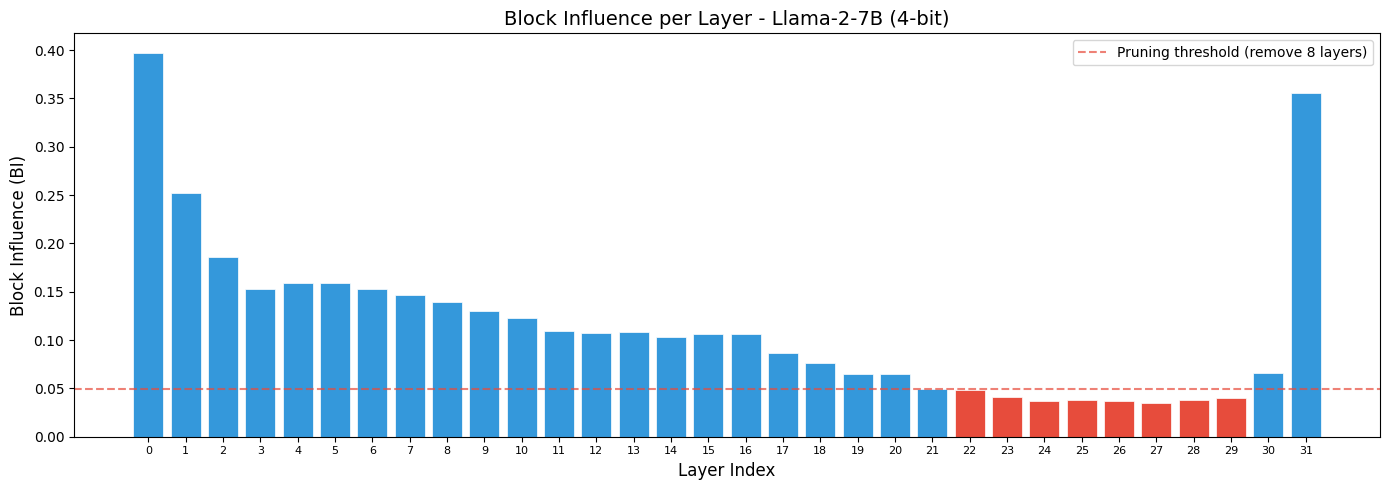

Saved: bi_scores.png

Original layers: 32
Layers to remove: 8 (25%)
Remaining layers: 24


In [ ]:
# How many layers to prune?
# Paper removes ~25% as a good baseline. For 32-layer Llama-2-7B, that's 8 layers.
N_PRUNE = 8  # ~25% of 32 layers

# Show the plot with pruning threshold highlighted
plot_bi_scores(bi_scores, n_prune=N_PRUNE)

print(f"\nOriginal layers: {NUM_LAYERS}")
print(f"Layers to remove: {N_PRUNE} ({N_PRUNE/NUM_LAYERS*100:.0f}%)")
print(f"Remaining layers: {NUM_LAYERS - N_PRUNE}")

In [ ]:
# Actually remove the layers
removed = remove_layers(model, bi_scores, N_PRUNE)

print(f"\nPruned model now has {len(model.model.layers)} layers.")
print(f"Remaining params: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Removing 8 layers: [22, 23, 24, 25, 26, 27, 28, 29]

Pruned model now has 24 layers.
Remaining params: 2.69B


---
## 7. Evaluate Pruned Model Perplexity

Now we run the same perplexity evaluation on the pruned model.
Compare this against the baseline we computed in section 5.5.

In [ ]:
# Reuse the same evaluate_perplexity function from section 5.5
print("Evaluating PRUNED model perplexity on WikiText-2 test set...")
pruned_ppl = evaluate_perplexity(model, test_encoding, seqlen=SEQLEN)

print(f"\nBaseline PPL (unpruned): {baseline_ppl:.2f}")
print(f"Pruned PPL ({N_PRUNE} layers removed): {pruned_ppl:.2f}")
print(f"PPL increase: {pruned_ppl - baseline_ppl:.2f} ({((pruned_ppl - baseline_ppl) / baseline_ppl) * 100:.1f}%)")

Evaluating PRUNED model perplexity on WikiText-2 test set...


Evaluating PPL: 100%|██████████| 666/666 [35:21<00:00,  3.19s/it]


Baseline PPL (unpruned): 7.53
Pruned PPL (8 layers removed): 37.56
PPL increase: 30.03 (398.8%)


# 7.5 Measurement
Measure the new speed of the pruned model and calculates your exact speedup multiplier.



In [ ]:
print("=== Benchmarking PRUNED Llama-2-7B ===")
pruned_metrics = benchmark_inference(model, tokenizer, max_new_tokens=100)

speedup = pruned_metrics['tokens_per_second'] / baseline_metrics['tokens_per_second']
print(f"Total Throughput Speedup Multiplier: {speedup:.2f}x")


Both `max_new_tokens` (=10) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Benchmarking PRUNED Llama-2-7B ===
Performing warmup run...


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating 100 tokens...
----------------------------------------
Speed: 16.14 tokens/sec
VRAM Peak: 3.7 GB
----------------------------------------
Total Throughput Speedup Multiplier: 1.63x


---
## 8. Evaluate: Generation Quality (Sanity Check)

Quick qualitative test - does the pruned model still produce coherent text?

In [ ]:
def generate_text(model, tokenizer, prompt, max_new_tokens=100):
    """Quick helper to generate text from a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


# A few test prompts to see if the pruned model still makes sense
test_prompts = [
    "The theory of relativity states that",
    "In a large neural network, the deeper layers",
    "The capital of France is",
]

print("=" * 70)
print("PRUNED MODEL GENERATION SAMPLES")
print("=" * 70)
for prompt in test_prompts:
    output = generate_text(model, tokenizer, prompt)
    print(f"\nPrompt: {prompt}")
    print(f"Output: {output}")
    print("-" * 70)

Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PRUNED MODEL GENERATION SAMPLES


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: The theory of relativity states that
Output: The theory of relativity states that time is slower inside objects that are accelerated by gravity. Einzelnes Projektteilnehmer. EAC/Eir­Lir­Stud. 594/00, EIRMAG 291.
Download The Theory Of Time Relations In The Theory Of Einstein-Ricor [...] ,,, Prep.
----------------------------------------------------------------------


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: In a large neural network, the deeper layers
Output: In a large neural network, the deeper layers usually take the responsibility of generating large and complex feature dimensions in the feature dimension vectors generated by input layer and lower layer. kwiet is defined with the parameter k in.
Quoc L. V. Hoardowne Incl. I will show the time and computational cost for creating the dataset. , K.
This dataset is the dataset for the dataset of 2,000, 20012 images and videos on the internet. It is, of the data of
----------------------------------------------------------------------

Prompt: The capital of France is
Output: The capital of France is famous for both the famous monuments on every photo of Paris and its atmosphere, the atmosphere of romance and freedom, inspiration and possibilities. Unterscheidung dermoxine 200m is available. Buy Phantasilwespe. The price ranges from $03500350.
Sitting in this place to enjoy a world famous view and a cup of tea in hand will not be 

---
## 9. Save Pruned Model (Optional)

Save the pruned model so the team can load it directly without re-running pruning.

In [ ]:
# Uncomment to save
# SAVE_DIR = "llama2-7b-shortgpt-pruned"
# model.save_pretrained(SAVE_DIR)
# tokenizer.save_pretrained(SAVE_DIR)
# print(f"Saved pruned model to {SAVE_DIR}/")

---
## 10. Summary Table

Print a clean results summary for the report.

In [ ]:
print("\\n" + "=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"Model: {MODEL_ID}")
print(f"Quantization: 4-bit NF4 (double quant)")
print(f"Original layers: {NUM_LAYERS}")
print(f"Pruned layers: {N_PRUNE} ({(N_PRUNE/NUM_LAYERS)*100:.0f}%)")
print(f"Remaining layers: {NUM_LAYERS - N_PRUNE}")
print(f"Layers removed: {removed}")
print(f"Calibration: WikiText-2, {NSAMPLES} samples x {SEQLEN} tokens")
print("-" * 50)
print(f"Baseline PPL:     {baseline_ppl:.2f}")
print(f"Pruned model PPL: {pruned_ppl:.2f}")
print(f"PPL increase:     {pruned_ppl - baseline_ppl:.2f} ({((pruned_ppl - baseline_ppl) / baseline_ppl) * 100:.1f}%)")
print("-" * 50)
print(f"Baseline Speed:   {baseline_metrics['tokens_per_second']} tokens/sec")
print(f"Pruned Speed:     {pruned_metrics['tokens_per_second']} tokens/sec")
print(f"Speedup:          {speedup:.2f}x")
print(f"Baseline VRAM:    {baseline_metrics.get('max_vram_gb', 'N/A')} GB")
print(f"Pruned VRAM:      {pruned_metrics.get('max_vram_gb', 'N/A')} GB")
print("=" * 50)

\n==================================================
RESULTS SUMMARY
Model: meta-llama/Llama-2-7b-hf
Quantization: 4-bit NF4 (double quant)
Original layers: 32
Pruned layers: 8 (25%)
Remaining layers: 24
Layers removed: [22, 23, 24, 25, 26, 27, 28, 29]
Calibration: WikiText-2, 128 samples x 512 tokens
--------------------------------------------------
Baseline PPL:     7.53
Pruned model PPL: 37.56
PPL increase:     30.03 (398.8%)
--------------------------------------------------
Baseline Speed:   9.89 tokens/sec
Pruned Speed:     16.14 tokens/sec
Speedup:          1.63x
Baseline VRAM:    3.7 GB
Pruned VRAM:      3.7 GB


# 11. Load Phi-2, prune the model, and dispaly the results.
Loads Microsoft's Phi-2 model so we can test the paper's claims about redundancy existing across different, smaller architecture. Prune the model, calculate the BI scores, and run Benchmarking.

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
ShortGPT Analysis: Phi-2 Model
Testing the claim that layer redundancy exists across different architectures
Loading Phi-2 Model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Throughput: 22.35 tokens/sec
Peak VRAM: 5.76 GB
Pruning 8 Layers
Removing layers: [19, 20, 21, 22, 23, 24, 25, 26]
Pruned: 8 layers removed, 24 layers remain
PRUNED MODEL (After Pruning)
Evaluating Perplexity


Evaluating: 100%|██████████| 3/3 [00:00<00:00,  7.78it/s]
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Perplexity: 36.43
Measuring Inference Throughput


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Throughput: 35.70 tokens/sec
Peak VRAM: 5.75 GB


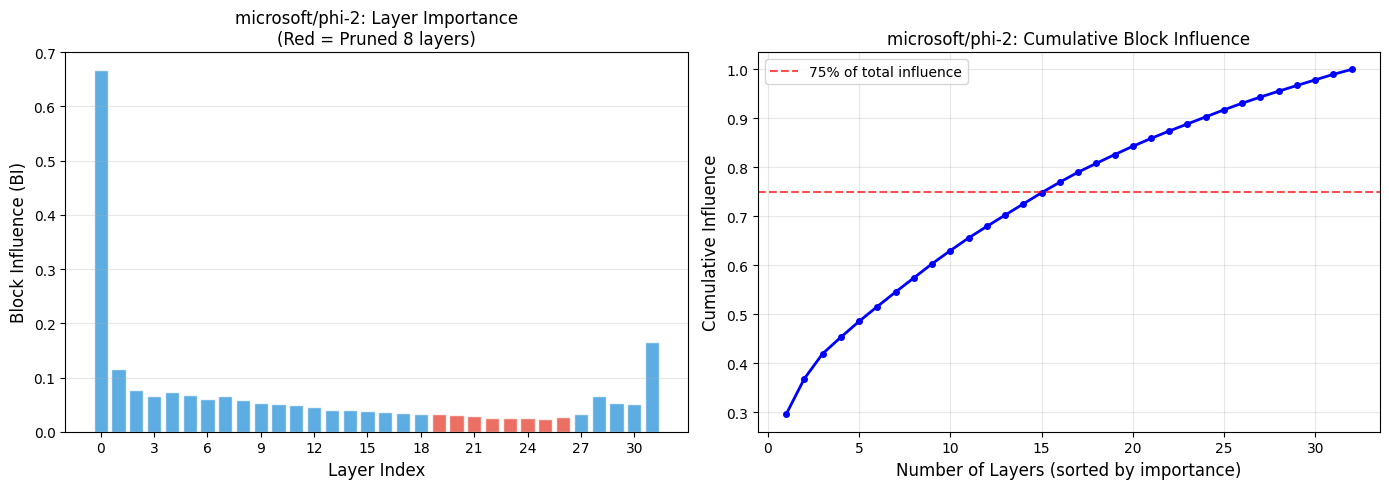

Saved plot to microsoft_phi-2_bi_analysis.png
FINAL SUMMARY

Model: microsoft/phi-2
   Layers: 32 → 24 (8 removed, 25%)
   Parameters: 2.15B

Redundancy Pattern:
   Most redundant: [25, 23, 24, 22, 26]
   Middle layers BI: 0.0393 (lowest)

Performance Impact:
   Perplexity (WikiText-2): 12.62 → 36.43
   Degradation: +23.81 (188.8%)

Efficiency Impact:
   Throughput: 22.35 → 35.70 tokens/sec
   Speedup: 1.60x
   VRAM: 5.76 → 5.75 GB

Conclusion: Phi-2 exhibits 0.0393 average BI in middle layers


In [ ]:
import random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from typing import List, Tuple

# ============================================
# Config
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_ID = "microsoft/phi-2"

# Calibration
SEQLEN = 512
NSAMPLES = 128

# ============================================
# Helper Functions
# ============================================

def load_phi2_model():
    """Load Phi-2 model with proper config."""
    print("Loading Phi-2 Model")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    config = AutoConfig.from_pretrained(MODEL_ID, trust_remote_code=True)
    config.pad_token_id = tokenizer.pad_token_id

    try:
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            config=config,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True,
        )
        print("Loaded in float16 mode")
    except Exception as e:
        print(f"Warning: {e}, falling back to float32")
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            config=config,
            torch_dtype=torch.float32,
            device_map="auto",
            trust_remote_code=True,
        )
        print("Loaded in float32 mode")

    model.eval()

    # Locate layers
    if hasattr(model, 'transformer') and hasattr(model.transformer, 'h'):
        num_layers = len(model.transformer.h)
        print(f"Found {num_layers} layers in model.transformer.h")
    elif hasattr(model, 'model') and hasattr(model.model, 'layers'):
        num_layers = len(model.model.layers)
        print(f"Found {num_layers} layers in model.model.layers")
    else:
        raise ValueError("Could not locate layers in model")

    print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

    return model, tokenizer, num_layers


def get_calibration_data(nsamples: int, seqlen: int, tokenizer, seed: int = 42) -> List[torch.Tensor]:
    """Load WikiText-2 calibration samples."""
    print("Loading Calibration Data (WikiText-2)")

    traindata = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

    # Filter empty strings and take subset for speed
    train_texts = [t.strip() for t in traindata["text"] if t.strip()]
    train_text = " ".join(train_texts[:300])

    trainenc = tokenizer(train_text, return_tensors="pt", truncation=True, max_length=None)

    random.seed(seed)
    samples = []
    max_start = max(0, trainenc.input_ids.shape[1] - seqlen - 1)

    for i in range(nsamples):
        if max_start > 0:
            start_idx = random.randint(0, max_start)
        else:
            start_idx = 0

        sample = trainenc.input_ids[:, start_idx:start_idx + seqlen]

        if sample.shape[1] < seqlen:
            padding = torch.full((1, seqlen - sample.shape[1]), tokenizer.pad_token_id, dtype=torch.long)
            sample = torch.cat([sample, padding], dim=1)

        samples.append(sample)

    print(f"Created {len(samples)} calibration samples")
    return samples


def block_influence(x_in: torch.Tensor, x_out: torch.Tensor) -> torch.Tensor:
    """Compute BI = 1 - cosine_similarity(input, output)."""
    B, S, D = x_in.shape
    flat_in = x_in.reshape(-1, D).float()
    flat_out = x_out.reshape(-1, D).float()
    sim = F.cosine_similarity(flat_in, flat_out, dim=-1)
    sim = sim.nan_to_num(nan=0.5)
    return 1.0 - sim


def compute_bi_scores(model, calibration_data: List[torch.Tensor], num_layers: int) -> List[float]:
    """Compute average BI scores for all layers."""
    print("Computing Block Influence Scores")

    bi_scores = [0.0] * num_layers
    total_tokens = 0

    with torch.no_grad():
        for inp in tqdm(calibration_data, desc="Processing samples"):
            inp = inp.to(DEVICE)
            outputs = model(
                input_ids=inp,
                output_hidden_states=True,
                return_dict=True
            )
            hidden_states = outputs.hidden_states
            total_tokens += inp.shape[1]

            for i in range(num_layers):
                bi = block_influence(hidden_states[i], hidden_states[i + 1])
                bi_scores[i] += bi.sum().item()

            # Free memory
            del outputs, hidden_states
            if DEVICE == "cuda":
                torch.cuda.empty_cache()

    # Average over all tokens
    if total_tokens > 0:
        bi_scores = [s / total_tokens for s in bi_scores]

    return bi_scores


def remove_layers(model, bi_scores: List[float], n_prune: int):
    """
    Remove layers with lowest BI scores.
    """
    print(f"Pruning {n_prune} Layers")

    layers_to_remove = np.argsort(bi_scores)[:n_prune].tolist()
    print(f"Removing layers: {sorted(layers_to_remove)}")

    # Locate layers container
    if hasattr(model, 'transformer') and hasattr(model.transformer, 'h'):
        layers = model.transformer.h
    elif hasattr(model, 'model') and hasattr(model.model, 'layers'):
        layers = model.model.layers
    else:
        raise ValueError("Cannot locate layers for pruning")

    # Remove from highest index to lowest to avoid index shifting
    for idx in sorted(layers_to_remove, reverse=True):
        del layers[idx]

    # Re-index layers if they have a layer_idx attribute
    for new_idx, layer in enumerate(layers):
        if hasattr(layer, 'self_attn') and hasattr(layer.self_attn, 'layer_idx'):
            layer.self_attn.layer_idx = new_idx

    # Update config
    if hasattr(model.config, 'num_hidden_layers'):
        model.config.num_hidden_layers = len(layers)

    print(f"Pruned: {n_prune} layers removed, {len(layers)} layers remain")
    return layers_to_remove


def evaluate_perplexity(model, tokenizer, seqlen: int = 128) -> float:
    """Evaluate perplexity on WikiText-2 test set."""
    print("Evaluating Perplexity")

    testdata = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    test_text = "\n\n".join([t for t in testdata["text"] if t.strip()])
    testenc = tokenizer(test_text, return_tensors="pt", truncation=True, max_length=None)

    test_ids = testenc.input_ids
    n_tokens = test_ids.shape[1]
    nlls = []

    with torch.no_grad():
        for i in tqdm(range(0, n_tokens - seqlen, seqlen), desc="Evaluating"):
            batch = test_ids[:, i:i + seqlen].to(DEVICE)
            outputs = model(input_ids=batch, use_cache=False, return_dict=True)

            logits = outputs.logits[:, :-1, :].float().contiguous()
            labels = batch[:, 1:].contiguous()

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                reduction="mean",
            )
            nlls.append(loss.item())

    avg_nll = np.mean(nlls)
    ppl = float(np.exp(avg_nll))
    print(f"Perplexity: {ppl:.2f}")
    return ppl


def measure_throughput(model, tokenizer, prompt: str, max_new_tokens: int = 100, runs: int = 5) -> Tuple[float, float]:
    """Measure tokens per second and peak VRAM usage."""
    print("Measuring Inference Throughput")

    # Warm-up
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=max_new_tokens)

    # Measure
    times = []
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()

    for _ in range(runs):
        start_time = time.time()
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)
        end_time = time.time()
        times.append(end_time - start_time)

    avg_time = np.mean(times)
    tokens_per_sec = max_new_tokens / avg_time

    # Peak memory
    peak_memory = 0
    if DEVICE == "cuda":
        peak_memory = torch.cuda.max_memory_allocated() / 1e9

    print(f"Throughput: {tokens_per_sec:.2f} tokens/sec")
    print(f"Peak VRAM: {peak_memory:.2f} GB")
    return tokens_per_sec, peak_memory


def plot_results(bi_scores: List[float], layers_removed: List[int], model_name: str):
    """Create plots."""
    num_layers = len(bi_scores)
    n_prune = len(layers_removed)

    plt.figure(figsize=(14, 5))

    # Plot 1: BI scores with pruning indicators
    plt.subplot(1, 2, 1)
    colors = ['#e74c3c' if i in layers_removed else '#3498db' for i in range(num_layers)]
    plt.bar(range(num_layers), bi_scores, color=colors, edgecolor='white', alpha=0.8)
    plt.xlabel("Layer Index", fontsize=12)
    plt.ylabel("Block Influence (BI)", fontsize=12)
    plt.title(f"{model_name}: Layer Importance\n(Red = Pruned {n_prune} layers)", fontsize=12)
    plt.xticks(range(0, num_layers, max(1, num_layers//10)))
    plt.grid(True, alpha=0.3, axis='y')

    # Plot 2: Cumulative influence
    plt.subplot(1, 2, 2)
    sorted_bi = sorted(bi_scores, reverse=True)
    cumulative = np.cumsum(sorted_bi) / np.sum(sorted_bi)
    plt.plot(range(1, num_layers+1), cumulative, 'b-', linewidth=2, marker='o', markersize=4)
    plt.axhline(y=0.75, color='r', linestyle='--', alpha=0.7, label='75% of total influence')
    plt.xlabel("Number of Layers (sorted by importance)", fontsize=12)
    plt.ylabel("Cumulative Influence", fontsize=12)
    plt.title(f"{model_name}: Cumulative Block Influence", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name.replace('/', '_')}_bi_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved plot to {model_name.replace('/', '_')}_bi_analysis.png")


# ============================================
# Main Execution
# ============================================

def main():
    """Run full ShortGPT analysis on Phi-2."""
    print("ShortGPT Analysis: Phi-2 Model")
    print("Testing the claim that layer redundancy exists across different architectures")

    # 1. Load model
    model, tokenizer, NUM_LAYERS = load_phi2_model()

    # 2. Load calibration data
    calibration_data = get_calibration_data(NSAMPLES, SEQLEN, tokenizer, SEED)

    # 3. Compute BI scores
    bi_scores = compute_bi_scores(model, calibration_data, NUM_LAYERS)

    ranked_layers = np.argsort(bi_scores)
    print("\nFull BI Ranking (lowest to highest):")
    for rank, layer in enumerate(ranked_layers):
      print(f"{rank+1:2d}. Layer {layer:2d}: {bi_scores[layer]:.4f}")

    # 4. Analyze redundancy pattern
    print("Redundancy Analysis")

    ranked = np.argsort(bi_scores)
    print(f"Most redundant (lowest BI): {ranked[:5].tolist()}")
    print(f"Most critical (highest BI): {ranked[-5:].tolist()}")

    # Regional averages
    mid_start = NUM_LAYERS // 3
    mid_end = 2 * NUM_LAYERS // 3
    early_avg = np.mean(bi_scores[:mid_start])
    mid_avg = np.mean(bi_scores[mid_start:mid_end])
    late_avg = np.mean(bi_scores[mid_end:])

    print(f"\nAverage BI by region:")
    print(f"  Early layers: {early_avg:.4f}")
    print(f"  Middle layers: {mid_avg:.4f}")
    print(f"  Late layers: {late_avg:.4f}")




    # 5. Baseline eval
    print("BASELINE (Before Pruning)")
    baseline_ppl = evaluate_perplexity(model, tokenizer, SEQLEN)
    baseline_tps, baseline_vram = measure_throughput(model, tokenizer, "The theory of", max_new_tokens=100)

    # 6. Prune layers
    N_PRUNE = max(1, NUM_LAYERS // 4)
    layers_removed = remove_layers(model, bi_scores, N_PRUNE)

    # 7. Post-pruning eval
    print("PRUNED MODEL (After Pruning)")
    pruned_ppl = evaluate_perplexity(model, tokenizer, SEQLEN)
    pruned_tps, pruned_vram = measure_throughput(model, tokenizer, "The theory of", max_new_tokens=100)

    # 8. Create visualizations
    plot_results(bi_scores, layers_removed, MODEL_ID)

    # 9. Final summary
    print("FINAL SUMMARY")

    print(f"\nModel: {MODEL_ID}")
    print(f"   Layers: {NUM_LAYERS} → {NUM_LAYERS - N_PRUNE} ({N_PRUNE} removed, {N_PRUNE/NUM_LAYERS*100:.0f}%)")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

    print(f"\nRedundancy Pattern:")
    print(f"   Most redundant: {ranked[:5].tolist()}")
    print(f"   Middle layers BI: {mid_avg:.4f} (lowest)")

    print(f"\nPerformance Impact:")
    print(f"   Perplexity (WikiText-2): {baseline_ppl:.2f} → {pruned_ppl:.2f}")
    print(f"   Degradation: +{pruned_ppl - baseline_ppl:.2f} ({((pruned_ppl - baseline_ppl) / baseline_ppl)*100:.1f}%)")

    print(f"\nEfficiency Impact:")
    print(f"   Throughput: {baseline_tps:.2f} → {pruned_tps:.2f} tokens/sec")
    print(f"   Speedup: {pruned_tps/baseline_tps:.2f}x")
    print(f"   VRAM: {baseline_vram:.2f} → {pruned_vram:.2f} GB")

    print(f"\nConclusion: Phi-2 exhibits {mid_avg:.4f} average BI in middle layers")



if __name__ == "__main__":
    main()